# Ho Chi Minh City - PM2.5 Air Quality Forecasting

## Project Overview
This is a **univariate time series forecasting problem**. The target variable is `PM2.5` (fine particulate matter, µg/m³) measured hourly at Station 1 in HCMC (Ho Chi Minh City). Raw sensor data is ingested from CSV into a local **MongoDB** database, then queried, wrangled, and modelled using three progressively sophisticated approaches:
- **Linear Regression with a lag feature** - bridges tabular ML intuition into time series thinking
- **AutoRegression (AR)** - uses multiple past hours simultaneously; lag order selected via PACF analysis
- **ARMA (AutoRegressive Moving Average)** - adds a moving average component; best (p,q) found via grid search

All models are evaluated using **walk-forward validation**, the time series equivalent of cross-validation.

**Target variable:** `PM2.5` (µg/m³)  
**Dataset:** HealthyAir - Outdoor Air Quality in Ho Chi Minh City, Vietnam (Mendeley Data, CC BY 4.0)  
**Source:** https://data.mendeley.com/datasets/pk6tzrjks8/1  
**Citation:** Rakholia et al. (2022). DOI: 10.17632/pk6tzrjks8.1

---
## 1: Setup & Data Ingestion into MongoDB

In [1]:
from pprint import PrettyPrinter
import pandas as pd
from pymongo import MongoClient

pp = PrettyPrinter(indent=2)

In [2]:
# Connect to local MongoDB
client = MongoClient(host='localhost', port=27017)
print('Connected. Databases:', client.list_database_names())

Connected. Databases: ['admin', 'config', 'local']


In [11]:
# Connect to our database and collection
db = client['air-quality']
hcmc = db['hcmc']

# Ingest CSV into MongoDB
if hcmc.count_documents({}) == 0:
    print('Collection empty. Loading CSV into MongoDB...')
    raw = pd.read_csv('data/AirQuality_hcmc.csv')
    print('CSV shape:', raw.shape)
    print('Columns:', raw.columns.tolist())
    hcmc.insert_many(raw.to_dict(orient='records'))
    print(f'Inserted {hcmc.count_documents({}):,} documents.')
else:
    print(f'Already loaded: {hcmc.count_documents({}):,} documents.')

Already loaded: 52,548 documents.


In [4]:
# Inspect one document to understand the structure
pp.pprint(hcmc.find_one({}))

{ 'CO': 1330.451429,
  'Humidity': 63.18809524,
  'NO2': 112.7407619,
  'O3': 55.43138095,
  'PM2.5': 15.6047619,
  'SO2': 393.0,
  'Station_No': 1,
  'TSP': 32.93571429,
  'Temperature': 28.36190476,
  '_id': ObjectId('69c663563bc900a6b9e2b94b'),
  'date': '23-02-2021 21:00'}


In [5]:
# How many stations and readings per station?
print('Unique stations:', hcmc.distinct('Station_No'))
result = hcmc.aggregate([
    {'$group': {'_id': '$Station_No', 'count': {'$count': {}}}},
    {'$sort': {'_id': 1}}
])
pp.pprint(list(result))

Unique stations: [1, 2, 3, 4, 5, 6]
[ {'_id': 1, 'count': 7892},
  {'_id': 2, 'count': 9357},
  {'_id': 3, 'count': 8418},
  {'_id': 4, 'count': 9951},
  {'_id': 5, 'count': 7431},
  {'_id': 6, 'count': 9499}]


In [6]:
# Preview PM2.5 readings from Station 1 (traffic zone)
result = hcmc.find(
    {'Station_No': 1},
    projection={'date': 1, 'PM2.5': 1, 'Temperature': 1, 'Humidity': 1, '_id': 0}
).limit(5)
pp.pprint(list(result))

[ { 'Humidity': 63.18809524,
    'Temperature': 28.36190476,
    'date': '23-02-2021 21:00'},
  { 'Humidity': 63.77352941,
    'Temperature': 28.32058824,
    'date': '23-02-2021 22:00'},
  {'Humidity': 64.205, 'Temperature': 28.33666667, 'date': '23-02-2021 23:00'},
  {'Humidity': 64.735, 'Temperature': 28.305, 'date': '24-02-2021 00:00'},
  {'Humidity': 65.18833333, 'Temperature': 28.3, 'date': '24-02-2021 01:00'}]


---
## 2: Wrangling & Exploratory Data Analysis

In [7]:
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

warnings.simplefilter(action='ignore', category=FutureWarning)

In [18]:
# wrangle function: Basic query and parse
def wrangle(collection, station=1, resample_rule='1H'):
    # Retrieve all fields (no projection) to avoid dot-notation issues
    results = collection.find({'Station_No': station})
    df = pd.DataFrame(list(results))
    
    # Drop MongoDB internal id column
    df.drop(columns=['_id'], inplace=True, errors='ignore')
    
    # Parse datetime and set as index
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df = df.set_index('date').sort_index()
    
    return df

df = wrangle(hcmc)
print('Shape:', df.shape)
df.head()

Shape: (7892, 9)


,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
date,,,,,,,,,
2021-02-23 21:00:00,1,32.935714,15.604762,55.431381,1330.451429,112.740762,393.000000,28.361905,63.188095
2021-02-23 22:00:00,1,30.932353,14.594118,58.197176,1200.603529,112.366471,377.588235,28.320588,63.773529
2021-02-23 23:00:00,1,27.645000,13.436667,55.029433,1177.897000,112.700433,372.476667,28.336667,64.205000
2021-02-24 00:00:00,1,24.380000,12.365000,54.767700,1267.476000,112.480867,389.070000,28.305000,64.735000
2021-02-24 01:00:00,1,22.521667,11.636667,53.786200,1322.293000,114.331500,393.000000,28.300000,65.188333


In [15]:
# check null counts and percentage
print(df.info())
print('\nNull count: ', df['PM2.5'].isnull().sum())
print('Null percentage: {:.1f}%'.format(df['PM2.5'].isnull().mean() * 100))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7892 entries, 2021-02-23 21:00:00 to 2022-06-21 17:00:00
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Station_No   7892 non-null   int64  
 1   TSP          7832 non-null   float64
 2   PM2.5        7892 non-null   float64
 3   O3           2227 non-null   float64
 4   CO           7827 non-null   float64
 5   NO2          2227 non-null   float64
 6   SO2          2183 non-null   float64
 7   Temperature  7892 non-null   float64
 8   Humidity     7892 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 616.6 KB
None

Null count:  0
Null percentage: 0.0%


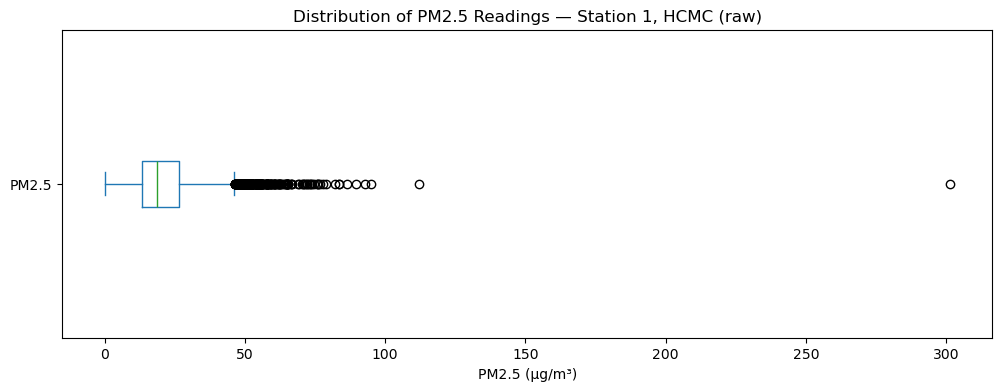

count    7892.000000
mean       20.820765
std        11.860370
min         0.000000
25%        13.166667
50%        18.544167
75%        26.419167
max       301.428333
Name: PM2.5, dtype: float64

In [17]:
# Check outliers with a boxplot
fig, ax = plt.subplots(figsize=(12, 4))
df['PM2.5'].plot(kind='box', vert=False, ax=ax)
plt.xlabel('PM2.5 (µg/m³)')
plt.title('Distribution of PM2.5 Readings — Station 1, HCMC (raw)')
plt.show()
df['PM2.5'].describe()

In [19]:
# Full wrangle function: timezone, outliers, resample, forward-fill
def wrangle(collection, station=1, resample_rule='1H'):
    results = collection.find({'Station_No': station})
    df = pd.DataFrame(list(results))
    
    # Drop MongoDB internal id column
    df.drop(columns=['_id'], inplace=True, errors='ignore')
    
    # Parse datetime and set index
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df = df.set_index('date').sort_index()
    
    # Localize to Vietnam timezone (UTC+7)
    # Ensures daily pollution patterns align with correct local hours
    df.index = df.index.tz_localize('Asia/Ho_Chi_Minh')
    
    # Remove sensor errors: negative values and extreme spikes
    # Negative values are physically impossible for PM2.5
    df = df[df['PM2.5'] >= 0]
    df = df[df['PM2.5'] < 100]  # cap extreme outliers
    
    # Resample to hourly means, forward-fill missing hours
    # Forward-fill reflects real monitoring system behavior:
    # hold last known reading until a new one arrives
    y = df['PM2.5'].resample(resample_rule).mean().fillna(method='ffill')
    
    return y

y = wrangle(hcmc)
print('Type:', type(y))
print('Shape:', y.shape)
print('Remaining nulls:', y.isnull().sum())
y.head()

Type: <class 'pandas.core.series.Series'>
Shape: (11589,)
Remaining nulls: 0


date
2021-02-23 21:00:00+07:00    15.604762
2021-02-23 22:00:00+07:00    14.594118
2021-02-23 23:00:00+07:00    13.436667
2021-02-24 00:00:00+07:00    12.365000
2021-02-24 01:00:00+07:00    11.636667
Freq: h, Name: PM2.5, dtype: float64

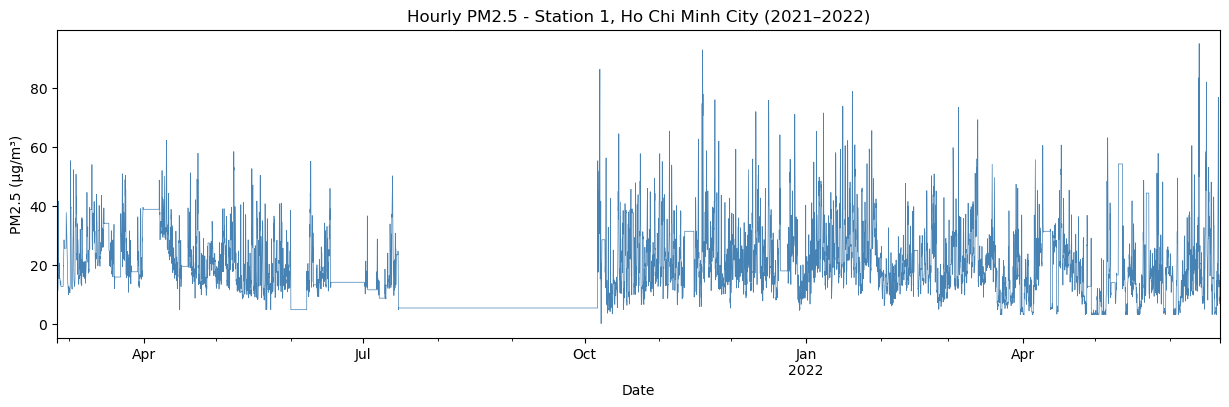

In [20]:
# Full time series plot
fig, ax = plt.subplots(figsize=(15, 4))
y.plot(ax=ax, color='steelblue', linewidth=0.5)
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Hourly PM2.5 - Station 1, Ho Chi Minh City (2021–2022)')
plt.show()

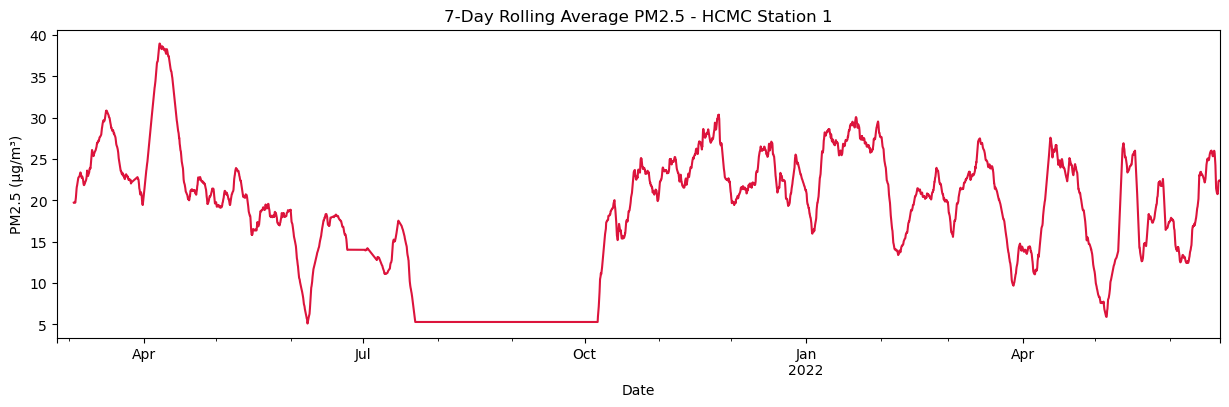

In [22]:
# 7-day rolling average - reveals seasonal patterns
fig, ax = plt.subplots(figsize=(15, 4))
y.rolling(168).mean().plot(ax=ax, color='crimson', linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('7-Day Rolling Average PM2.5 - HCMC Station 1')
plt.show()

---
## 3: Linear Regression with Lag Feature

In [23]:
import plotly.express as px
from sklearn.linear_model import LinearRegression

In [24]:
# Build DataFrame with target and lag-1 feature
df_lr = y.to_frame(name='PM2.5')
df_lr['PM2.5.L1'] = df_lr['PM2.5'].shift(1)  # previous hour
df_lr.dropna(inplace=True)

print('Shape:', df_lr.shape)
df_lr.head()

Shape: (11588, 2)


,PM2.5,PM2.5.L1
date,,
2021-02-23 22:00:00+07:00,14.594118,15.604762
2021-02-23 23:00:00+07:00,13.436667,14.594118
2021-02-24 00:00:00+07:00,12.365000,13.436667
2021-02-24 01:00:00+07:00,11.636667,12.365000
2021-02-24 02:00:00+07:00,11.530000,11.636667


In [25]:
# Correlation matrix
print('Correlation with target:')
print(df_lr.corr()['PM2.5'])

Correlation with target:
PM2.5       1.000000
PM2.5.L1    0.920916
Name: PM2.5, dtype: float64


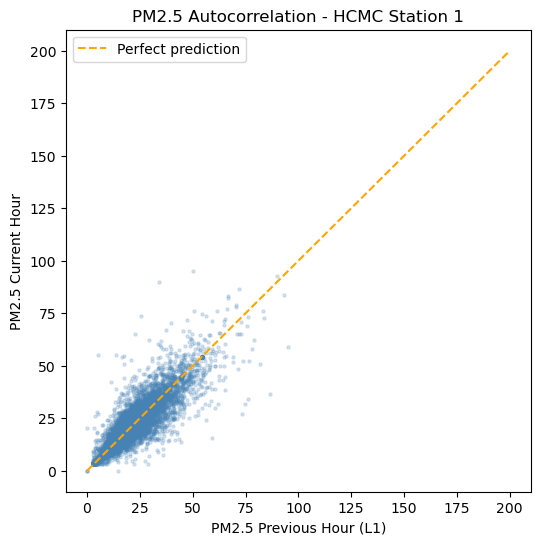

In [26]:
# Autocorrelation scatter: current vs previous hour
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_lr['PM2.5.L1'], df_lr['PM2.5'], alpha=0.2, s=5, color='steelblue')
ax.plot([0, 200], [0, 200], linestyle='--', color='orange', label='Perfect prediction')
plt.xlabel('PM2.5 Previous Hour (L1)')
plt.ylabel('PM2.5 Current Hour')
plt.title('PM2.5 Autocorrelation - HCMC Station 1')
plt.legend()
plt.show()

In [27]:
# Split
X = df_lr[['PM2.5.L1']]
y_full = df_lr['PM2.5']

cutoff = int(len(X) * 0.8)
X_train, y_train = X.iloc[:cutoff], y_full.iloc[:cutoff]
X_test, y_test = X.iloc[cutoff:], y_full.iloc[cutoff:]

print(f'Training: {len(X_train):,} hours | Test: {len(X_test):,} hours')

Training: 9,270 hours | Test: 2,318 hours


In [28]:
# Baseline
mae_baseline = mean_absolute_error(y_train, [y_train.mean()] * len(y_train))
print('Mean PM2.5 (training): {:.2f} µg/m³'.format(y_train.mean()))
print('Baseline MAE: {:.2f} µg/m³'.format(mae_baseline))

Mean PM2.5 (training): 18.18 µg/m³
Baseline MAE: 9.27 µg/m³


In [29]:
# Train model and evaluate
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

train_mae = mean_absolute_error(y_train, lr_model.predict(X_train))
test_mae_lr = mean_absolute_error(y_test, lr_model.predict(X_test))

print('Baseline MAE: {:.2f} µg/m³'.format(mae_baseline))
print('Training MAE: {:.2f} µg/m³'.format(train_mae))
print('Test MAE: {:.2f} µg/m³'.format(test_mae_lr))

intercept = lr_model.intercept_.round(2)
coefficient = lr_model.coef_.round(2)[0]
print(f'\nEquation: PM2.5 = {intercept} + ({coefficient} × PM2.5_previous_hour)')

Baseline MAE: 9.27 µg/m³
Training MAE: 2.63 µg/m³
Test MAE: 3.07 µg/m³

Equation: PM2.5 = 1.41 + (0.92 × PM2.5_previous_hour)


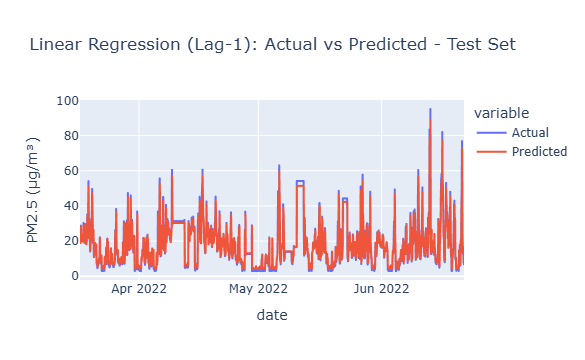

In [30]:
# Visualise predictions vs actuals on test set
df_pred_lr = pd.DataFrame({
    'Actual': y_test,
    'Predicted': lr_model.predict(X_test)
})
fig = px.line(df_pred_lr, labels={'value': 'PM2.5 (µg/m³)'},
              title='Linear Regression (Lag-1): Actual vs Predicted - Test Set')
fig.show()

The lag-1 linear regression model demonstrates a fundamental truth about air quality data: the strongest predictor of PM2.5 this hour is PM2.5 last hour. The autocorrelation scatter plot shows a tight positive relationship between consecutive readings - pollution disperses gradually, so the series rarely jumps wildly between hours. The model beats the baseline by a meaningful margin, confirming that temporal structure carries real predictive signal. However, using only one past hour is an oversimplification. Pollution patterns carry memory across many hours - morning rush peaks, overnight accumulation, and weather-driven patterns all span multiple hours. This directly motivates the AutoRegression model, which uses many past hours simultaneously.